# Stage 6 Classifier Results Inspection

This notebook loads classifier validation outputs and gives quick sanity checks plus visual comparisons.

It expects artifacts produced by `scripts/03_run_classifiers.py` under:
- `results/classifier/<method>/scores.parquet`
- `results/classifier/<method>/meta.json`

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "results").exists() and (cwd / "scripts").exists():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "results").exists() and (cwd.parent / "scripts").exists():
        return cwd.parent
    raise FileNotFoundError(
        "Could not resolve repository root from current working directory. "
        "Open the notebook in the project workspace root or notebooks folder."
    )


REPO_ROOT = resolve_repo_root()
CLASSIFIER_RESULTS_DIR = REPO_ROOT / "results" / "classifier"
SPLITS_META_PATH = REPO_ROOT / "data" / "processed" / "splits_meta.json"

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))
from src.statistics import nadeau_bengio_se

splits_meta = json.loads(SPLITS_META_PATH.read_text(encoding="utf-8"))
TEST_SIZE = float(splits_meta["test_size"])
N_SAMPLES = int(splits_meta["n_samples"])
N_TEST = int(round(TEST_SIZE * N_SAMPLES))
N_TRAIN = N_SAMPLES - N_TEST

print(f"Repo root: {REPO_ROOT}")
print(f"Classifier results dir: {CLASSIFIER_RESULTS_DIR}")
print(
    f"Nadeau-Bengio: n_samples={N_SAMPLES} test_size={TEST_SIZE:.4f} "
    f"-> n_train={N_TRAIN} n_test={N_TEST} (ratio={N_TEST / N_TRAIN:.4f})"
)

Repo root: C:\Programmering\exjobb\MSc26_Proteomics
Classifier results dir: C:\Programmering\exjobb\MSc26_Proteomics\results\classifier
Nadeau-Bengio: n_samples=512 test_size=0.2000 -> n_train=410 n_test=102 (ratio=0.2488)


## Load Scores And Metadata

This cell discovers all methods with `scores.parquet` and combines them into one dataframe for comparison.

In [2]:
def load_classifier_results(base_dir: Path) -> tuple[pd.DataFrame, dict[str, dict]]:
    if not base_dir.exists():
        raise FileNotFoundError(f"Classifier results directory not found: {base_dir}")

    frames: list[pd.DataFrame] = []
    meta_by_method: dict[str, dict] = {}

    for method_dir in sorted(base_dir.iterdir()):
        if not method_dir.is_dir():
            continue

        scores_path = method_dir / "scores.parquet"
        meta_path = method_dir / "meta.json"
        if not scores_path.exists():
            continue

        method_name = method_dir.name
        df = pd.read_parquet(scores_path).copy()
        df["method"] = method_name
        df["k"] = df["k"].astype(str)
        frames.append(df)

        if meta_path.exists():
            meta_by_method[method_name] = json.loads(meta_path.read_text(encoding="utf-8"))

    if not frames:
        raise FileNotFoundError(
            f"No scores.parquet files found under: {base_dir}"
        )

    all_scores = pd.concat(frames, ignore_index=True)
    return all_scores, meta_by_method


scores, meta_by_method = load_classifier_results(CLASSIFIER_RESULTS_DIR)

print(f"Methods loaded: {sorted(scores['method'].unique().tolist())}")
print(f"Total rows: {len(scores):,}")
print(f"Columns: {scores.columns.tolist()}")

display(scores.head())

Methods loaded: ['mi', 'random', 'ttest']
Total rows: 2,250
Columns: ['split_id', 'classifier', 'k', 'auc', 'aupr', 'n_features_actual', 'method']


,split_id,classifier,k,auc,aupr,n_features_actual,method
0,0,LogisticRegression,10,0.521212,0.166125,10,mi
1,0,RandomForest,10,0.594697,0.238838,10,mi
2,0,XGBoost,10,0.663636,0.322615,10,mi
3,0,LogisticRegression,25,0.646212,0.248957,25,mi
4,0,RandomForest,25,0.630303,0.332221,25,mi


In [3]:
required_cols = {"split_id", "classifier", "k", "auc", "aupr", "n_features_actual", "method"}
missing_cols = required_cols.difference(scores.columns)
if missing_cols:
    raise ValueError(f"Missing expected columns: {sorted(missing_cols)}")

coverage = (
    scores.groupby("method", as_index=False)
    .agg(
        n_rows=("split_id", "size"),
        n_splits=("split_id", "nunique"),
        n_classifiers=("classifier", "nunique"),
        nan_auc=("auc", lambda s: int(s.isna().sum())),
        nan_aupr=("aupr", lambda s: int(s.isna().sum())),
    )
)

k_values_by_method = (
    scores.groupby("method")["k"]
    .apply(lambda s: sorted(s.unique().tolist()))
    .rename("k_values")
    .reset_index()
)

coverage = coverage.merge(k_values_by_method, on="method", how="left")

print("Coverage by method")
display(coverage)

if meta_by_method:
    print("Loaded metadata keys:")
    for method, meta in sorted(meta_by_method.items()):
        print(f"- {method}: {sorted(meta.keys())}")

Coverage by method


,method,n_rows,n_splits,n_classifiers,nan_auc,nan_aupr,k_values
0,mi,750,50,3,147,147,"[10, 100, 25, 50, native]"
1,random,750,50,3,0,0,"[10, 100, 25, 50, native]"
2,ttest,750,50,3,6,6,"[10, 100, 25, 50, native]"


Loaded metadata keys:
- mi: ['cohort_path', 'failed_fits', 'includes_native', 'method', 'n_rows', 'n_splits', 'runtime_seconds', 'scores_path', 'seed', 'selections_path', 'split_seed_rule', 'splits_path', 'topk_values']
- random: ['cohort_path', 'failed_fits', 'includes_native', 'method', 'n_rows', 'n_splits', 'runtime_seconds', 'scores_path', 'seed', 'selections_path', 'split_seed_rule', 'splits_path', 'topk_values']
- ttest: ['cohort_path', 'failed_fits', 'includes_native', 'method', 'n_rows', 'n_splits', 'runtime_seconds', 'scores_path', 'seed', 'selections_path', 'split_seed_rule', 'splits_path', 'topk_values']


## Aggregate Performance Table

`auc_se_nb` / `aupr_se_nb` are Nadeau–Bengio corrected standard errors of the mean across the random 80/20 splits, accounting for shared test patients across folds. `auc_sd_split` / `aupr_sd_split` show the raw split-to-split spread (i.e. variability of the per-split metric, not population SE).

In [4]:
k_order = [str(k) for k in [10, 25, 50, 100]] + ["native"]
scores["k"] = pd.Categorical(scores["k"], categories=k_order, ordered=True)

summary = (
    scores.groupby(["method", "classifier", "k"], observed=True, as_index=False)
    .agg(
        n_rows=("split_id", "size"),
        n_splits=("split_id", "nunique"),
        auc_mean=("auc", "mean"),
        auc_sd_split=("auc", "std"),
        aupr_mean=("aupr", "mean"),
        aupr_sd_split=("aupr", "std"),
        n_features_mean=("n_features_actual", "mean"),
        n_features_min=("n_features_actual", "min"),
        n_features_max=("n_features_actual", "max"),
    )
)

summary["auc_se_nb"] = summary.apply(
    lambda r: nadeau_bengio_se(r["auc_sd_split"], int(r["n_splits"]), N_TRAIN, N_TEST),
    axis=1,
)
summary["aupr_se_nb"] = summary.apply(
    lambda r: nadeau_bengio_se(r["aupr_sd_split"], int(r["n_splits"]), N_TRAIN, N_TEST),
    axis=1,
)

summary = summary.sort_values(["classifier", "k", "method"]).reset_index(drop=True)

display(summary)

leaderboard = summary.sort_values(["auc_mean", "aupr_mean"], ascending=False).head(20)
print("Top 20 method/classifier/k combinations by mean AUC then mean AUPR")
display(leaderboard)

,method,classifier,k,n_rows,n_splits,auc_mean,auc_sd_split,aupr_mean,aupr_sd_split,n_features_mean,n_features_min,n_features_max,auc_se_nb,aupr_se_nb
0,mi,LogisticRegression,10,50,50,0.532833,0.087647,0.200196,0.065295,10.00,10,10,0.045440,0.033852
1,random,LogisticRegression,10,50,50,0.516848,0.078990,0.184407,0.055276,10.00,10,10,0.040952,0.028657
2,ttest,LogisticRegression,10,50,50,0.566727,0.066999,0.208347,0.056938,10.00,10,10,0.034735,0.029519
3,mi,LogisticRegression,25,50,50,0.559561,0.092891,0.215942,0.070664,25.00,25,25,0.048159,0.036635
4,random,LogisticRegression,25,50,50,0.548879,0.075951,0.204519,0.056555,25.00,25,25,0.039376,0.029321
5,ttest,LogisticRegression,25,50,50,0.592303,0.078927,0.222970,0.062767,25.00,25,25,0.040919,0.032541
6,mi,LogisticRegression,50,50,50,0.588409,0.085364,0.229302,0.072575,50.00,50,50,0.044256,0.037626
7,random,LogisticRegression,50,50,50,0.593364,0.059958,0.219885,0.049467,50.00,50,50,0.031085,0.025646
8,ttest,LogisticRegression,50,50,50,0.612667,0.066905,0.239772,0.062530,50.00,50,50,0.034686,0.032418
9,mi,LogisticRegression,100,50,50,0.587318,0.087608,0.227301,0.063888,100.00,100,100,0.045419,0.033122


Top 20 method/classifier/k combinations by mean AUC then mean AUPR


,method,classifier,k,n_rows,n_splits,auc_mean,auc_sd_split,aupr_mean,aupr_sd_split,n_features_mean,n_features_min,n_features_max,auc_se_nb,aupr_se_nb
11,ttest,LogisticRegression,100,50,50,0.637682,0.064440,0.254348,0.064466,100.0,100,100,0.033408,0.033422
26,ttest,RandomForest,100,50,50,0.617712,0.071874,0.231290,0.061907,100.0,100,100,0.037262,0.032095
8,ttest,LogisticRegression,50,50,50,0.612667,0.066905,0.239772,0.062530,50.0,50,50,0.034686,0.032418
41,ttest,XGBoost,100,50,50,0.612197,0.071672,0.237061,0.076922,100.0,100,100,0.037157,0.039879
25,random,RandomForest,100,50,50,0.604061,0.082980,0.226506,0.060709,100.0,100,100,0.043020,0.031474
10,random,LogisticRegression,100,50,50,0.602061,0.070614,0.229101,0.066420,100.0,100,100,0.036609,0.034435
24,mi,RandomForest,100,50,50,0.598621,0.071322,0.222042,0.060878,100.0,100,100,0.036976,0.031561
7,random,LogisticRegression,50,50,50,0.593364,0.059958,0.219885,0.049467,50.0,50,50,0.031085,0.025646
21,mi,RandomForest,50,50,50,0.593136,0.075247,0.231735,0.070237,50.0,50,50,0.039011,0.036414
5,ttest,LogisticRegression,25,50,50,0.592303,0.078927,0.222970,0.062767,25.0,25,25,0.040919,0.032541


## Visual Comparison

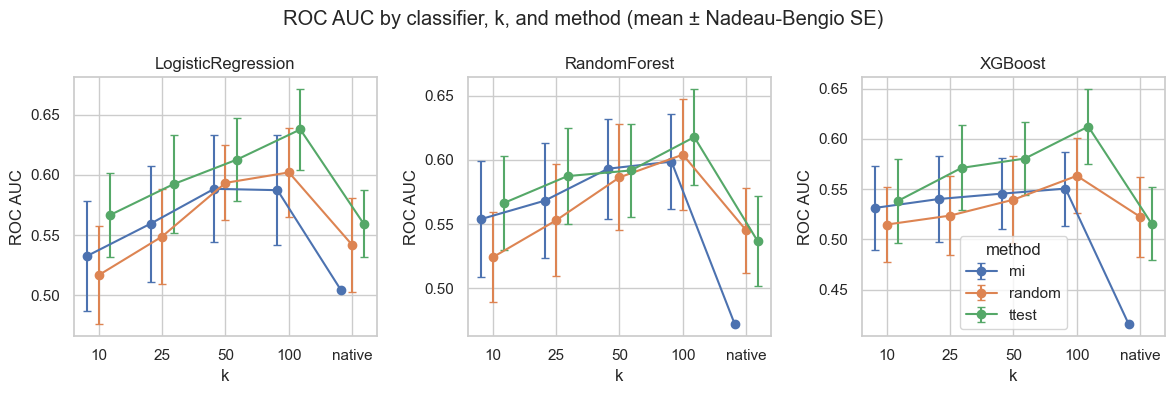

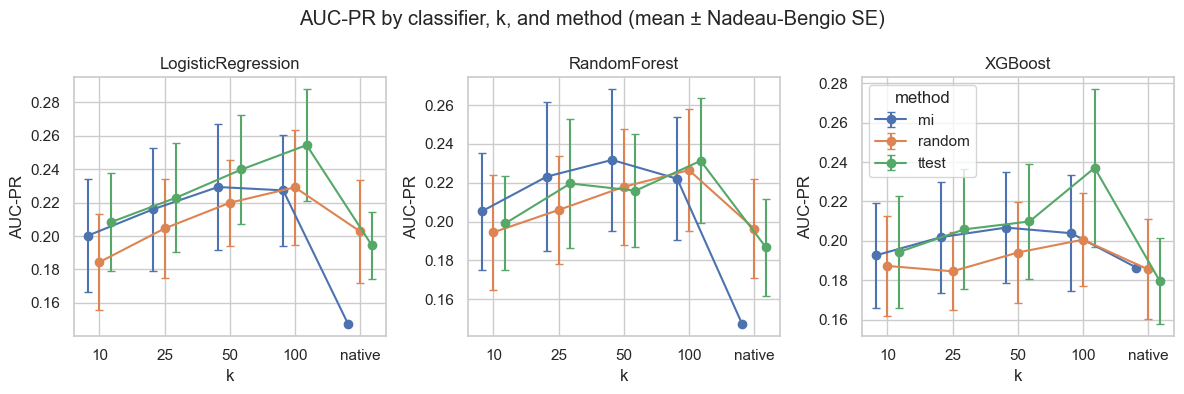

In [5]:
CROSS_METHOD_PVALUES_PATH = REPO_ROOT / "results" / "comparison" / "cross_method_pvalues.parquet"
pvalues_for_stars = (
    pd.read_parquet(CROSS_METHOD_PVALUES_PATH)
    if CROSS_METHOD_PVALUES_PATH.exists()
    else None
)


def p_to_stars(p: float) -> str:
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


classifiers = sorted(summary["classifier"].unique().tolist())
methods = sorted(summary["method"].unique().tolist())
palette = dict(zip(methods, sns.color_palette(n_colors=len(methods))))

for metric, title in [("auc", "ROC AUC"), ("aupr", "AUC-PR")]:
    mean_col = f"{metric}_mean"
    se_col = f"{metric}_se_nb"

    fig, axes = plt.subplots(
        1, len(classifiers), figsize=(4 * len(classifiers), 4), sharey=False
    )
    if len(classifiers) == 1:
        axes = [axes]

    x_positions = np.arange(len(k_order))
    dodge = 0.18

    for ax, clf in zip(axes, classifiers):
        sub = summary[summary["classifier"] == clf]
        method_y = {}
        method_yerr = {}
        for i, method in enumerate(methods):
            row_lookup = sub[sub["method"] == method].set_index("k")
            y = [row_lookup.loc[k, mean_col] if k in row_lookup.index else np.nan for k in k_order]
            yerr = [row_lookup.loc[k, se_col] if k in row_lookup.index else np.nan for k in k_order]
            method_y[method] = y
            method_yerr[method] = yerr
            offset = (i - (len(methods) - 1) / 2) * dodge
            ax.errorbar(
                x_positions + offset,
                y,
                yerr=yerr,
                fmt="o-",
                color=palette[method],
                label=method,
                capsize=3,
            )

        if len(methods) == 2 and pvalues_for_stars is not None:
            clf_pvals = pvalues_for_stars[
                (pvalues_for_stars["classifier"] == clf)
                & (pvalues_for_stars["metric"] == metric)
            ]
            for xi, k in enumerate(k_order):
                row = clf_pvals[clf_pvals["k"].astype(str) == str(k)]
                if row.empty:
                    continue
                stars = p_to_stars(float(row.iloc[0]["p_value"]))
                if not stars:
                    continue
                top = np.nanmax(
                    [
                        (method_y[m][xi] or 0) + (method_yerr[m][xi] or 0)
                        for m in methods
                    ]
                )
                ax.annotate(
                    stars,
                    xy=(xi, top),
                    xytext=(0, 6),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                )

        ax.set_title(clf)
        ax.set_xlabel("k")
        ax.set_ylabel(title)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(k_order)
    axes[-1].legend(title="method", loc="best")
    fig.suptitle(f"{title} by classifier, k, and method (mean ± Nadeau-Bengio SE)")
    fig.tight_layout()
    plt.show()

In [6]:
issues = scores[(scores["auc"].isna()) | (scores["aupr"].isna()) | (scores["n_features_actual"] == 0)].copy()

print(f"Rows with NaN metric or zero features: {len(issues):,} / {len(scores):,}")
if len(issues) > 0:
    issue_summary = (
        issues.groupby(["method", "classifier", "k"], observed=True, as_index=False)
        .agg(n_rows=("split_id", "size"))
        .sort_values("n_rows", ascending=False)
    )
    display(issue_summary)
else:
    print("No issues detected in metrics or feature counts.")

Rows with NaN metric or zero features: 153 / 2,250


,method,classifier,k,n_rows
0,mi,LogisticRegression,native,49
1,mi,RandomForest,native,49
2,mi,XGBoost,native,49
3,ttest,LogisticRegression,native,2
4,ttest,RandomForest,native,2
5,ttest,XGBoost,native,2


In [7]:
def mean_table_for_k(k_value: str) -> pd.DataFrame:
    subset = scores[scores["k"] == k_value]
    return (
        subset.groupby(["method", "classifier"], observed=True, as_index=False)
        .agg(
            auc_mean=("auc", "mean"),
            aupr_mean=("aupr", "mean"),
            n_features_mean=("n_features_actual", "mean"),
        )
        .sort_values(["classifier", "auc_mean"], ascending=[True, False])
    )

print("Mean performance at k=50")
display(mean_table_for_k("50"))

print("Mean performance at native cutoff")
display(mean_table_for_k("native"))

Mean performance at k=50


,method,classifier,auc_mean,aupr_mean,n_features_mean
6,ttest,LogisticRegression,0.612667,0.239772,50.0
3,random,LogisticRegression,0.593364,0.219885,50.0
0,mi,LogisticRegression,0.588409,0.229302,50.0
1,mi,RandomForest,0.593136,0.231735,50.0
7,ttest,RandomForest,0.591773,0.215887,50.0
4,random,RandomForest,0.586394,0.217891,50.0
8,ttest,XGBoost,0.580439,0.209874,50.0
2,mi,XGBoost,0.545576,0.206764,50.0
5,random,XGBoost,0.539576,0.194118,50.0


Mean performance at native cutoff


,method,classifier,auc_mean,aupr_mean,n_features_mean
6,ttest,LogisticRegression,0.559438,0.194494,11.40
3,random,LogisticRegression,0.541758,0.202748,20.00
0,mi,LogisticRegression,0.504545,0.147136,0.02
4,random,RandomForest,0.545076,0.196398,20.00
7,ttest,RandomForest,0.536750,0.186836,11.40
1,mi,RandomForest,0.471970,0.147065,0.02
5,random,XGBoost,0.522439,0.185570,20.00
8,ttest,XGBoost,0.515578,0.179647,11.40
2,mi,XGBoost,0.415530,0.186508,0.02


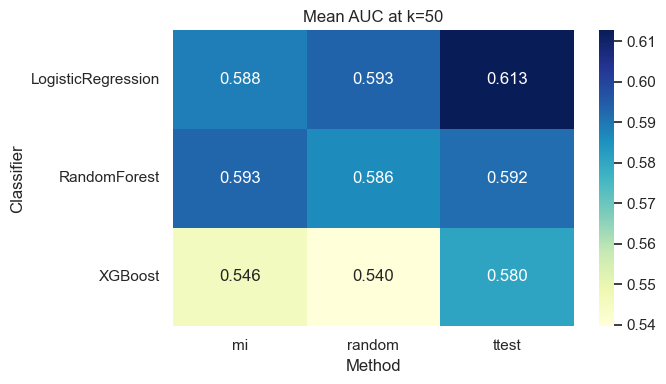

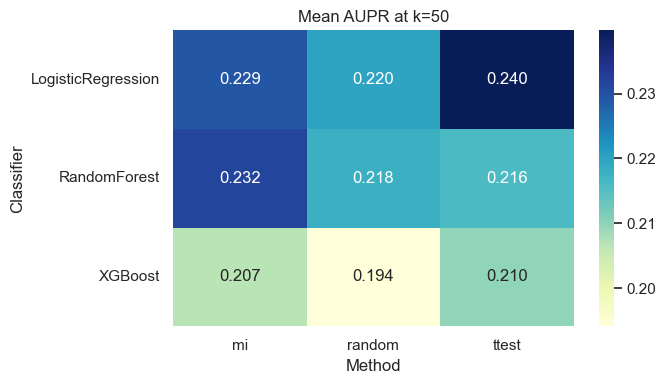

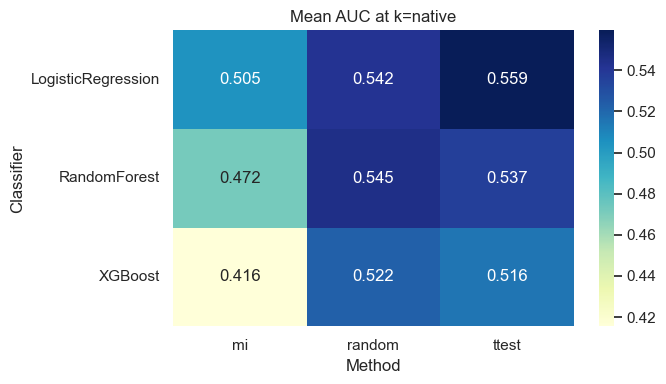

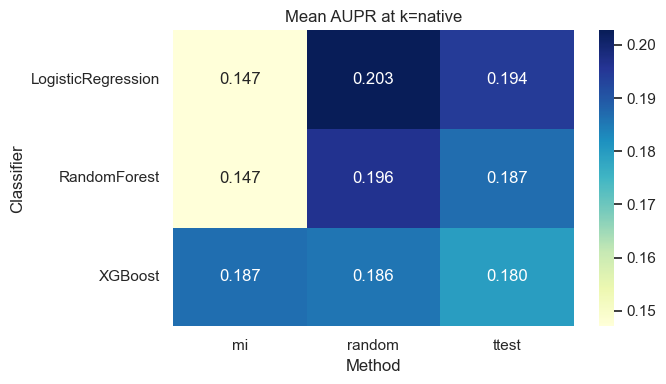

In [8]:
for metric, k_value in [("auc", "50"), ("aupr", "50"), ("auc", "native"), ("aupr", "native")]:
    heat = (
        scores[scores["k"] == k_value]
        .groupby(["classifier", "method"], observed=True)[metric]
        .mean()
        .unstack("method")
    )

    plt.figure(figsize=(7, 4))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlGnBu")
    plt.title(f"Mean {metric.upper()} at k={k_value}")
    plt.xlabel("Method")
    plt.ylabel("Classifier")
    plt.tight_layout()
    plt.show()

## Cross-method significance (paired permutation test)

Loads `results/comparison/cross_method_pvalues.parquet` produced by `scripts/06_aggregate_results.py`. Each row reports a two-sided paired sign-flip permutation p-value for one `(classifier, k, metric, method_a, method_b)` comparison. Stars: `*** p<0.001`, `** p<0.01`, `* p<0.05`, `ns` otherwise. Unadjusted p-values; no multiple-testing correction applied.

In [9]:
pvalues = pd.read_parquet(CROSS_METHOD_PVALUES_PATH)
pvalues["k"] = pd.Categorical(pvalues["k"].astype(str), categories=k_order, ordered=True)
pvalues["stars"] = pvalues["p_value"].apply(p_to_stars)

print(f"Loaded {CROSS_METHOD_PVALUES_PATH.name}: shape={pvalues.shape}")
display(pvalues.head())

Loaded cross_method_pvalues.parquet: shape=(30, 11)


,classifier,k,metric,method_a,method_b,n_splits_common,mean_diff,p_value,n_permutations,seed,stars
0,LogisticRegression,10,auc,random,ttest,50,-0.049879,0.000300,10000,0,***
1,LogisticRegression,10,aupr,random,ttest,50,-0.023939,0.020898,10000,0,*
2,LogisticRegression,100,auc,random,ttest,50,-0.035621,0.001600,10000,0,**
3,LogisticRegression,100,aupr,random,ttest,50,-0.025246,0.016798,10000,0,*
4,LogisticRegression,25,auc,random,ttest,50,-0.043424,0.001400,10000,0,**


In [10]:
table = (
    pvalues.loc[
        :,
        [
            "classifier",
            "k",
            "metric",
            "method_a",
            "method_b",
            "n_splits_common",
            "mean_diff",
            "p_value",
            "stars",
        ],
    ]
    .sort_values(["classifier", "metric", "k", "method_a", "method_b"])
    .reset_index(drop=True)
)


def _highlight_significant(row: pd.Series) -> list[str]:
    if pd.notna(row["p_value"]) and row["p_value"] < 0.05:
        return ["background-color: #fff3a3"] * len(row)
    return [""] * len(row)


styled = (
    table.style.apply(_highlight_significant, axis=1)
    .format({"mean_diff": "{:+.3f}", "p_value": "{:.2e}"})
    .set_caption("Cross-method paired permutation p-values (unadjusted)")
)

display(styled)
print(f"Significant rows (p<0.05): {(table['p_value'] < 0.05).sum()} / {len(table)}")

,classifier,k,metric,method_a,method_b,n_splits_common,mean_diff,p_value,stars
0,LogisticRegression,10,auc,random,ttest,50,-0.050,3.00e-04,***
1,LogisticRegression,25,auc,random,ttest,50,-0.043,1.40e-03,**
2,LogisticRegression,50,auc,random,ttest,50,-0.019,6.94e-02,ns
3,LogisticRegression,100,auc,random,ttest,50,-0.036,1.60e-03,**
4,LogisticRegression,native,auc,random,ttest,48,-0.020,1.50e-01,ns
5,LogisticRegression,10,aupr,random,ttest,50,-0.024,2.09e-02,*
6,LogisticRegression,25,aupr,random,ttest,50,-0.018,7.34e-02,ns
7,LogisticRegression,50,aupr,random,ttest,50,-0.020,3.00e-02,*
8,LogisticRegression,100,aupr,random,ttest,50,-0.025,1.68e-02,*
9,LogisticRegression,native,aupr,random,ttest,48,+0.007,4.55e-01,ns


Significant rows (p<0.05): 13 / 30


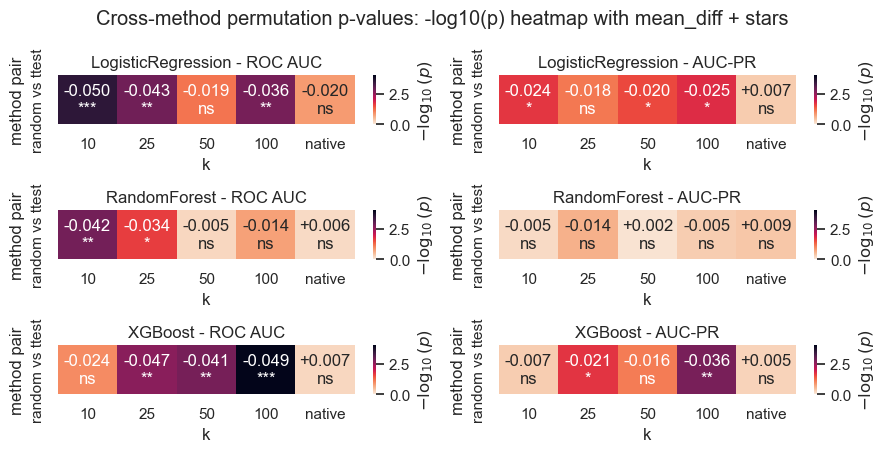

Saved: C:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures\cross_method_pvalue_heatmap.png


In [11]:
metrics = [("auc", "ROC AUC"), ("aupr", "AUC-PR")]
classifiers_pv = sorted(pvalues["classifier"].unique().tolist())

pvalues["pair"] = pvalues["method_a"].astype(str) + " vs " + pvalues["method_b"].astype(str)
pair_order = sorted(pvalues["pair"].unique().tolist())

fig, axes = plt.subplots(
    len(classifiers_pv),
    len(metrics),
    figsize=(4.5 * len(metrics), 1.0 + 1.2 * len(pair_order) * len(classifiers_pv)),
    squeeze=False,
)

for r, clf in enumerate(classifiers_pv):
    for c, (metric, metric_title) in enumerate(metrics):
        ax = axes[r][c]
        sub = pvalues[(pvalues["classifier"] == clf) & (pvalues["metric"] == metric)]

        color_mat = (
            sub.pivot(index="pair", columns="k", values="p_value")
            .reindex(index=pair_order, columns=k_order)
            .apply(lambda col: -np.log10(col.clip(lower=1e-10)))
        )

        annot_mat = sub.pivot(index="pair", columns="k", values="mean_diff").reindex(
            index=pair_order, columns=k_order
        )
        stars_mat = sub.pivot(index="pair", columns="k", values="stars").reindex(
            index=pair_order, columns=k_order
        )
        annot_text = annot_mat.copy().astype(object)
        for i in annot_mat.index:
            for j in annot_mat.columns:
                v = annot_mat.loc[i, j]
                s = stars_mat.loc[i, j]
                if pd.isna(v):
                    annot_text.loc[i, j] = ""
                else:
                    annot_text.loc[i, j] = f"{v:+.3f}\n{s}" if s else f"{v:+.3f}"

        sns.heatmap(
            color_mat,
            annot=annot_text.values,
            fmt="",
            cmap="rocket_r",
            vmin=0.0,
            vmax=4.0,
            cbar_kws={"label": r"$-\log_{10}(p)$"},
            ax=ax,
        )
        ax.set_title(f"{clf} - {metric_title}")
        ax.set_xlabel("k")
        ax.set_ylabel("method pair")

fig.suptitle("Cross-method permutation p-values: -log10(p) heatmap with mean_diff + stars")
fig.tight_layout()

heatmap_out = REPO_ROOT / "results" / "comparison" / "figures" / "cross_method_pvalue_heatmap.png"
heatmap_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(heatmap_out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {heatmap_out}")